In [1]:
import pandas as pd
import numpy as np
import sklearn.impute as skl_imp
from sklearn.experimental import enable_iterative_imputer
from sklearn.preprocessing import PowerTransformer

from funciones import *

In [2]:
# Abrir archivo raw_data
data_folder = "../data"
df = pd.read_parquet(f"{data_folder}/raw_data.parquet")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 78535 entries, 0 to 78534
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Fecha               78535 non-null  datetime64[ns]
 1   Close               78535 non-null  float64       
 2   Ticker              78535 non-null  str           
 3   Beta                70795 non-null  float64       
 4   MarketCap           78256 non-null  float64       
 5   EnterpriseValue     78256 non-null  float64       
 6   PE_Trailing         78086 non-null  float64       
 7   EnterpriseToEbitda  78256 non-null  float64       
 8   PriceToBook         78047 non-null  float64       
 9   operatingMargins    78496 non-null  float64       
 10  profitMargins       78326 non-null  float64       
 11  returnOnEquity      78117 non-null  float64       
 12  ReturnOnAssets      78287 non-null  float64       
 13  debtToEquity        78287 non-null  float64       
 14  c

In [ ]:
columnas_a_eliminar = ['Close']
df.drop(columnas_a_eliminar, axis=1, inplace=True)

# Formatear market cap y EnterpriseValue en billions
df["MarketCap"] = df["MarketCap"] / 10**9
df["EnterpriseValue"] = df["EnterpriseValue"] / 10**9

In [4]:
# Formatear market cap y EnterpriseValue en billions
df["MarketCap"] = df["MarketCap"] / 10**9
df["EnterpriseValue"] = df["EnterpriseValue"] / 10**9

# Variables continuas

In [5]:
# Distribucion de variables continuas
df.describe().round(2).T

,count,mean,min,25%,50%,75%,max,std
Fecha,78535,2024-10-04 17:53:37.974151680,2022-06-06 00:00:00,2023-12-11 00:00:00,2024-10-07 00:00:00,2025-08-04 00:00:00,2026-06-01 00:00:00,NaN
Beta,70795.0,0.91,-1.49,0.49,0.86,1.24,7.73,0.6
MarketCap,78256.0,105.45,0.7,18.09,34.77,75.49,5482.18,338.55
EnterpriseValue,78256.0,117.47,2.61,22.6,43.29,89.29,5482.62,343.04
PE_Trailing,78086.0,-15.11,-105950.34,15.44,24.09,35.82,6121.58,1959.39
EnterpriseToEbitda,78256.0,22.41,-1843.02,11.01,15.71,21.82,3287.8,89.27
PriceToBook,78047.0,7.05,-1168.96,1.86,3.71,8.04,1430.58,53.22
operatingMargins,78496.0,0.19,-1.6,0.11,0.18,0.26,0.93,0.15
profitMargins,78326.0,0.13,-1.72,0.07,0.12,0.2,1.04,0.16
returnOnEquity,78117.0,0.22,-36.77,0.08,0.16,0.31,39.48,2.27


In [6]:
# Coeficientes de asimetria
df.select_dtypes(include="number").skew()

Beta                   1.160583
MarketCap              8.297698
EnterpriseValue        8.154292
PE_Trailing          -39.147317
EnterpriseToEbitda    13.935838
PriceToBook            7.778228
operatingMargins      -0.464271
profitMargins         -1.953745
returnOnEquity         0.900606
ReturnOnAssets         0.708521
debtToEquity          -3.818208
currentRatio           6.760552
dtype: float64

Cont


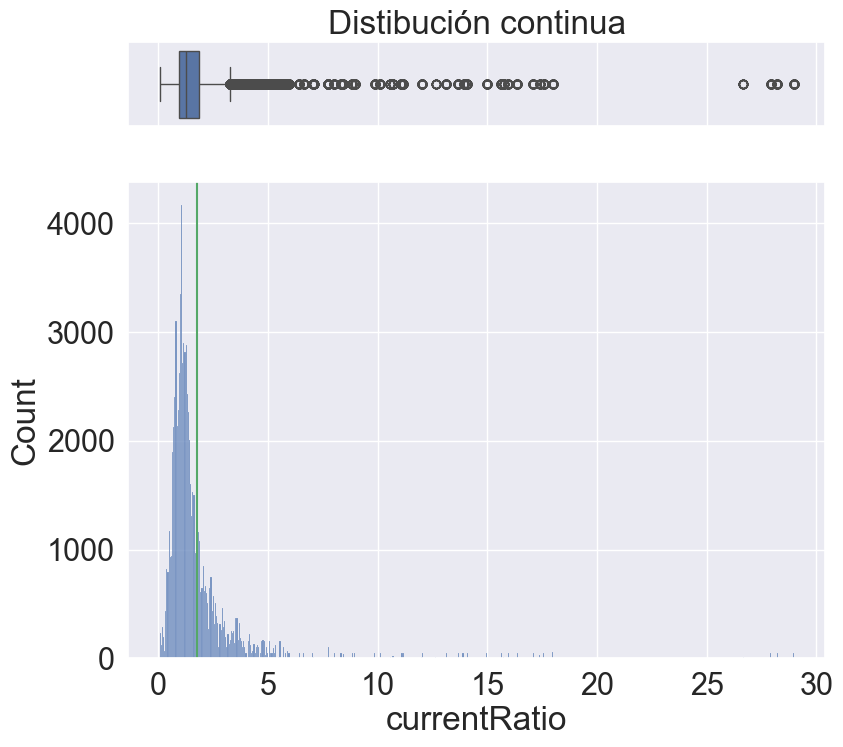

In [7]:
# Graficar
columna_a_graficar = 'currentRatio' # indicar columna para el grafico
plot(df[columna_a_graficar])

In [8]:
# Transformacion yeo-johnson
pt = PowerTransformer(method='yeo-johnson', standardize=True)
columnas_a_transformar = ['PriceToBook', 'returnOnEquity', 'PE_Trailing', 'EnterpriseToEbitda']
for columna in columnas_a_transformar:
    df[f'{columna}_Transformed'] = pt.fit_transform(df[[columna]])
    # Elimino la columna sin transformar
    df.drop(columna, axis=1, inplace=True)

In [9]:
# Transformaciones logarítmicas
columnas_a_transformar = ['MarketCap', 'EnterpriseValue', 'debtToEquity', 'currentRatio']
for columna in columnas_a_transformar:
    df[f'{columna}_log'] = np.log1p(df[columna])
    df.drop(columna, axis=1, inplace=True)

# Coeficientes de asimetria actualizado
df.select_dtypes(include="number").skew()

c:\Users\sebas\anaconda3\envs\ml-dev\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


Beta                              1.160583
operatingMargins                 -0.464271
profitMargins                    -1.953745
ReturnOnAssets                    0.708521
PriceToBook_Transformed           4.225311
returnOnEquity_Transformed       -0.187999
PE_Trailing_Transformed           9.987614
EnterpriseToEbitda_Transformed    9.382470
MarketCap_log                     1.137948
EnterpriseValue_log               1.082176
debtToEquity_log                  2.406304
currentRatio_log                  1.871235
dtype: float64

## Gestion de Outliers

Se winsorizan los valores atipicos en las variables continuas que cumplan los siguientes criterios:

Para variables simetricas:
* A mas de 3 desviaciones tipicas de la media.
* Mas de 3 rangos intercuartilicos.

Para variables asimetricas (modulo del coeficiente de asimetrica mayor a 1):
* A mas de 3 MADs de la mediana.
* Mas de 3 rangos intercuartilicos.

In [10]:
# Outliers
df_cont = df.select_dtypes(include="number")
df_winsor = df_cont.apply(lambda x: gestiona_outliers(x, clas='winsor'))

Beta
operatingMargins
profitMargins
ReturnOnAssets
PriceToBook_Transformed
returnOnEquity_Transformed
PE_Trailing_Transformed
EnterpriseToEbitda_Transformed
MarketCap_log
EnterpriseValue_log
debtToEquity_log
currentRatio_log


In [11]:
# Coeficientes de asimetria actualizados luego de winsorizar
df_winsor.skew()

Beta                              0.756429
operatingMargins                  0.518677
profitMargins                     0.150397
ReturnOnAssets                    0.572939
PriceToBook_Transformed           0.222423
returnOnEquity_Transformed        0.941871
PE_Trailing_Transformed           0.926392
EnterpriseToEbitda_Transformed    0.948233
MarketCap_log                     1.137817
EnterpriseValue_log               1.082095
debtToEquity_log                  1.492139
currentRatio_log                  1.219675
dtype: float64

Cont


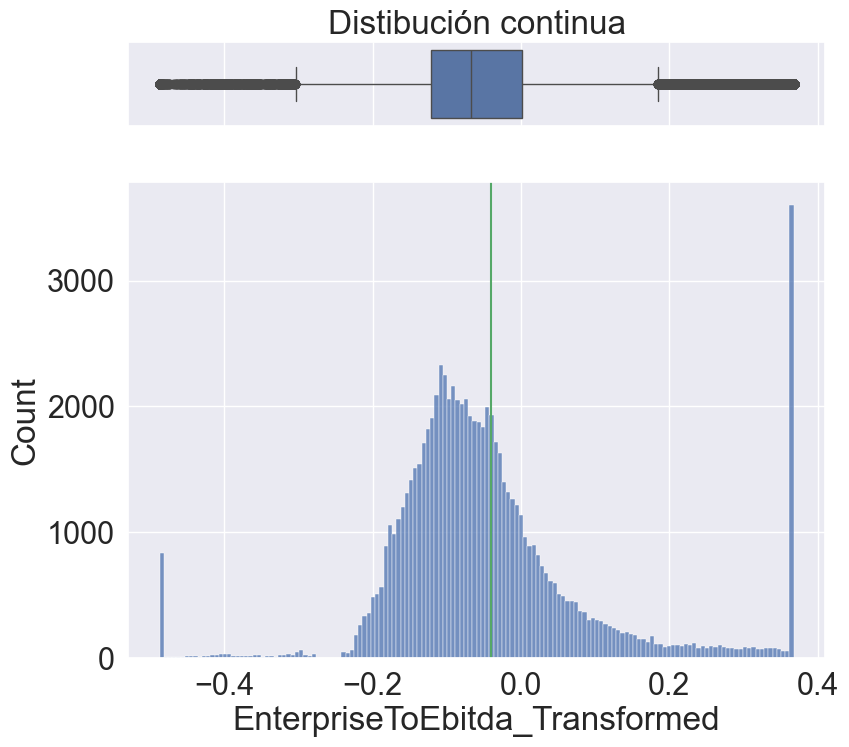

In [12]:
# Visualizar cambios
columna_a_graficar = 'EnterpriseToEbitda_Transformed' # indicar columna para el grafico
plot(df_winsor[columna_a_graficar])

In [13]:
df_winsor.describe().T

,count,mean,std,min,25%,50%,75%,max
Beta,70795.0,0.905588,0.586154,-1.487400,0.490700,0.863500,1.242250,3.503800
operatingMargins,78496.0,0.191615,0.140724,-0.359800,0.106500,0.178100,0.261100,0.741900
profitMargins,78326.0,0.135860,0.130152,-0.353200,0.066900,0.121500,0.197100,0.603100
ReturnOnAssets,78287.0,0.079438,0.077272,-0.227700,0.032900,0.063700,0.117600,0.388700
PriceToBook_Transformed,78047.0,-0.017155,0.165127,-0.434778,-0.084878,-0.049727,0.031651,0.381318
returnOnEquity_Transformed,78117.0,-0.008233,0.467997,-3.153453,-0.058042,-0.021720,0.043068,3.267516
PE_Trailing_Transformed,78086.0,-0.051213,0.062082,-0.238309,-0.084931,-0.064094,-0.033865,0.119356
EnterpriseToEbitda_Transformed,78256.0,-0.040801,0.143041,-0.486959,-0.120734,-0.067550,0.001306,0.367428
MarketCap_log,78256.0,3.747392,1.076754,0.530479,2.949395,3.577087,4.337213,8.510533
EnterpriseValue_log,78256.0,3.950097,1.037177,1.284235,3.161220,3.790832,4.503016,8.530855


# Variables Categoricas

In [14]:
df_non_numeric = df.select_dtypes(exclude='number')

In [15]:
# Valores unicos
df_non_numeric.nunique()

Fecha          209
Ticker         455
Sector          11
SubIndustry    119
DateAdded      338
dtype: int64

In [16]:
# Convertir Sector y SubIndustrya category
df_non_numeric['Sector'] = df_non_numeric['Sector'].astype('category')
df_non_numeric['SubIndustry'] = df_non_numeric['SubIndustry'].astype('category')

# Valores unicos en Sector
df_non_numeric['Sector'].value_counts()

Sector
Industrials               13624
Information Technology    12297
Health Care                9813
Consumer Discretionary     8245
Consumer Staples           6422
Financials                 5511
Real Estate                5270
Utilities                  5113
Materials                  4460
Communication Services     4044
Energy                     3736
Name: count, dtype: int64

In [17]:
# Valores unicos en SubIndustry
df_non_numeric['SubIndustry'].value_counts()

SubIndustry
Health Care Equipment                           2957
Electric Utilities                              2550
Application Software                            2461
Semiconductors                                  2425
Industrial Machinery & Supplies & Components    2416
                                                ... 
Food Retail                                      166
Homefurnishing Retail                            166
Footwear                                         157
Health Care Technology                           115
Heavy Electrical Equipment                       115
Name: count, Length: 119, dtype: int64

In [18]:
# Se agrupan las categorías de SubIndustry con valor único por la categoría "Other"
df_non_numeric['SubIndustry'] = reducir_cardinalidad(df_non_numeric, 'SubIndustry')

In [18]:
df_non_numeric[df_non_numeric['Sector'].isnull()]

,Fecha,Ticker,Sector,SubIndustry,DateAdded


In [19]:
# Transformar DateAdded a datetime y convertir a YearsSinceAdded
df_non_numeric['DateAdded'] = pd.to_datetime(df_non_numeric['DateAdded'], errors='coerce')
df_non_numeric['YearsSinceAdded'] = round(((pd.Timestamp.now() - df_non_numeric['DateAdded']).dt.days / 365.25), 0)
df_non_numeric.drop('DateAdded', axis=1, inplace=True)

In [20]:
# Merge de variables continuas transformadas y variables no numericas
df_combined = pd.concat([df_non_numeric, df_winsor], axis=1)
df_combined.head()

,Fecha,Ticker,Sector,SubIndustry,YearsSinceAdded,Beta,operatingMargins,profitMargins,ReturnOnAssets,PriceToBook_Transformed,returnOnEquity_Transformed,PE_Trailing_Transformed,EnterpriseToEbitda_Transformed,MarketCap_log,EnterpriseValue_log,debtToEquity_log,currentRatio_log
0,2023-01-02,A,Health Care,Life Sciences Tools & Services,26.0,NaN,0.2363,0.1831,0.1191,0.033155,0.012275,-0.037732,0.020343,3.786161,3.824346,0.420025,1.108596
1,2023-01-09,A,Health Care,Life Sciences Tools & Services,26.0,NaN,0.2363,0.1831,0.1191,0.042659,0.012275,-0.032022,0.036227,3.845579,3.881600,0.420025,1.108596
2,2023-01-16,A,Health Care,Life Sciences Tools & Services,26.0,NaN,0.2363,0.1831,0.1191,0.041632,0.012275,-0.032642,0.034511,3.839323,3.875566,0.420025,1.108596
3,2023-01-23,A,Health Care,Life Sciences Tools & Services,26.0,NaN,0.2363,0.1831,0.1191,0.041395,0.012275,-0.032785,0.034116,3.837878,3.874173,0.420025,1.108596
4,2023-01-30,A,Health Care,Life Sciences Tools & Services,26.0,NaN,0.2363,0.1831,0.1191,0.040224,0.012275,-0.033491,0.032159,3.830688,3.867240,0.420025,1.108596


# Missings

In [21]:
df_combined.isnull().sum()

Fecha                                0
Ticker                               0
Sector                               0
SubIndustry                          0
YearsSinceAdded                      0
Beta                              7740
operatingMargins                    39
profitMargins                      209
ReturnOnAssets                     248
PriceToBook_Transformed            488
returnOnEquity_Transformed         418
PE_Trailing_Transformed            449
EnterpriseToEbitda_Transformed     279
MarketCap_log                      279
EnterpriseValue_log                279
debtToEquity_log                  5720
currentRatio_log                    78
dtype: int64

In [22]:
# Resto de las continuas: imputar multivariable con IterativeImputer
df_cont = df_combined.select_dtypes(include='number')
# Imputador: Chain equations
imputer_itImp = skl_imp.IterativeImputer(max_iter=10, random_state=0)

In [23]:
df_imputed = pd.DataFrame(imputer_itImp.fit_transform(df_cont),columns=df_cont.columns)
df_imputed.info()

<class 'pandas.DataFrame'>
RangeIndex: 78535 entries, 0 to 78534
Data columns (total 13 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   YearsSinceAdded                 78535 non-null  float64
 1   Beta                            78535 non-null  float64
 2   operatingMargins                78535 non-null  float64
 3   profitMargins                   78535 non-null  float64
 4   ReturnOnAssets                  78535 non-null  float64
 5   PriceToBook_Transformed         78535 non-null  float64
 6   returnOnEquity_Transformed      78535 non-null  float64
 7   PE_Trailing_Transformed         78535 non-null  float64
 8   EnterpriseToEbitda_Transformed  78535 non-null  float64
 9   MarketCap_log                   78535 non-null  float64
 10  EnterpriseValue_log             78535 non-null  float64
 11  debtToEquity_log                78535 non-null  float64
 12  currentRatio_log                78535 non-n

In [24]:
df_final = pd.concat([df_imputed, df_combined.select_dtypes(exclude='number')], axis=1)
df_final.info()

<class 'pandas.DataFrame'>
RangeIndex: 78535 entries, 0 to 78534
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   YearsSinceAdded                 78535 non-null  float64       
 1   Beta                            78535 non-null  float64       
 2   operatingMargins                78535 non-null  float64       
 3   profitMargins                   78535 non-null  float64       
 4   ReturnOnAssets                  78535 non-null  float64       
 5   PriceToBook_Transformed         78535 non-null  float64       
 6   returnOnEquity_Transformed      78535 non-null  float64       
 7   PE_Trailing_Transformed         78535 non-null  float64       
 8   EnterpriseToEbitda_Transformed  78535 non-null  float64       
 9   MarketCap_log                   78535 non-null  float64       
 10  EnterpriseValue_log             78535 non-null  float64       
 11  debtToEquity_

In [25]:
df_final.select_dtypes(include='number').skew()

YearsSinceAdded                   1.038451
Beta                              0.783139
operatingMargins                  0.518903
profitMargins                     0.146455
ReturnOnAssets                    0.567772
PriceToBook_Transformed           0.219718
returnOnEquity_Transformed        0.945503
PE_Trailing_Transformed           0.921548
EnterpriseToEbitda_Transformed    0.952235
MarketCap_log                     1.141550
EnterpriseValue_log               1.084038
debtToEquity_log                  0.056975
currentRatio_log                  1.219861
dtype: float64

In [26]:
# Guardar datos extraidos en fichero clean_data
df_final.to_parquet(f"{data_folder}/clean_data.parquet")